# IntentGuard: Resource-Efficient AI Agent

## Project Idea

Our first project filtered user messages to decide whether an AI response was needed.

IntentGuard improves this idea by placing a lightweight decision layer BEFORE the AI agent.

It asks:

**"Does this message actually need AI computation?"**

If NO → stay silent and do not call the AI agent.

If YES → send it to the AI agent.

The goal is to reduce unnecessary AI calls, tokens, latency, cost, and agent-resource usage while still handling genuine requests correctly.

## Example

"Thank you" → NO-OP → Silence

"Okay, got it" → NO-OP → Silence

"What is RAG?" → AI Agent

"Search today's news" → AI Agent + Tool

In [ ]:
## Step 1: Create Our Baseline

In [144]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

print("✅ Warnings hidden")

✅ Warnings hidden


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [1]:
messages = [
    "Thank you",
    "Okay",
    "I appreciate your help",
    "What is RAG?",
    "Explain AI agents",
    "Search today's news"
]

print("Messages received:", len(messages))

Messages received: 6


 Step 2: Intent Classification

First, we classify each message as:

- NO_ACTION → no AI needed
- TASK → AI is needed
- UNCLEAR → needs further evaluation

In [9]:
def classify_message(message):
    message = message.lower().strip()

    no_action = [
        "nice",
        "thank you",
        "thanks",
        "okay",
        "ok",
        "got it",
        "i appreciate your help",
        "perfect",
        "great",
        "bye"
    ]

    for phrase in no_action:
        if phrase in message:
            return "NO_ACTION"

    return "TASK"


# Test
for message in messages:
    print(message, "→", classify_message(message))

Thank you → NO_ACTION
Thanks a lot → NO_ACTION
Okay, got it → NO_ACTION
I appreciate your help → NO_ACTION
Perfect → NO_ACTION
Great → NO_ACTION
Bye → NO_ACTION
What is RAG? → TASK
Explain AI agents → TASK
What is machine learning? → TASK
Compare RAG and fine tuning → TASK
How does an AI agent work? → TASK
Search today's news → TASK
What is the weather today? → TASK
Calculate 25 times 18 → TASK
Help me understand embeddings → TASK
Tell me about LangSmith → TASK
Find information about AI agents → TASK
Nice → NO_ACTION
Got it → NO_ACTION


In [3]:
total_messages = len(messages)

no_action_count = 0
task_count = 0

for message in messages:
    result = classify_message(message)

    if result == "NO_ACTION":
        no_action_count += 1
    else:
        task_count += 1

print("Total messages:", total_messages)
print("AI calls needed:", task_count)
print("AI calls avoided:", no_action_count)

Total messages: 6
AI calls needed: 3
AI calls avoided: 3


here the result is correct 50% ai calls are stopped.
we will make a gate to route the message .

In [4]:
def intent_guard(message):
    result = classify_message(message)

    if result == "NO_ACTION":
        return "STOP"
    else:
        return "SEND_TO_AI"


for message in messages:
    print(message, "→", intent_guard(message))

Thank you → STOP
Okay → STOP
I appreciate your help → STOP
What is RAG? → SEND_TO_AI
Explain AI agents → SEND_TO_AI
Search today's news → SEND_TO_AI


 We'll create a fake agent so we can prove that IntentGuard blocks unnecessary calls.

In [5]:
agent_calls = 0

def ai_agent(message):
    global agent_calls
    agent_calls += 1
    print("🤖 AI AGENT CALLED:", message)


for message in messages:
    if intent_guard(message) == "SEND_TO_AI":
        ai_agent(message)

print("\nTotal AI agent calls:", agent_calls)

🤖 AI AGENT CALLED: What is RAG?
🤖 AI AGENT CALLED: Explain AI agents
🤖 AI AGENT CALLED: Search today's news

Total AI agent calls: 3


the gate stops unnecessary messages before they reach the agent.

In [6]:
messages = [
    "Thank you",
    "Thanks a lot",
    "Okay, got it",
    "I appreciate your help",
    "Perfect",
    "Great",
    "Bye",
    "What is RAG?",
    "Explain AI agents",
    "What is machine learning?",
    "Compare RAG and fine tuning",
    "How does an AI agent work?",
    "Search today's news",
    "What is the weather today?",
    "Calculate 25 times 18",
    "Help me understand embeddings",
    "Tell me about LangSmith",
    "Find information about AI agents",
    "Nice",
    "Got it"
]

print("Total test messages:", len(messages))

Total test messages: 20


running the classifier on all 20 messages

In [10]:
for message in messages:
    print(message, "→", classify_message(message))

Thank you → NO_ACTION
Thanks a lot → NO_ACTION
Okay, got it → NO_ACTION
I appreciate your help → NO_ACTION
Perfect → NO_ACTION
Great → NO_ACTION
Bye → NO_ACTION
What is RAG? → TASK
Explain AI agents → TASK
What is machine learning? → TASK
Compare RAG and fine tuning → TASK
How does an AI agent work? → TASK
Search today's news → TASK
What is the weather today? → TASK
Calculate 25 times 18 → TASK
Help me understand embeddings → TASK
Tell me about LangSmith → TASK
Find information about AI agents → TASK
Nice → NO_ACTION
Got it → NO_ACTION


In [11]:
total_messages = len(messages)

no_action_count = 0
task_count = 0

for message in messages:
    result = classify_message(message)

    if result == "NO_ACTION":
        no_action_count += 1
    else:
        task_count += 1

print("Total messages:", total_messages)
print("AI calls needed:", task_count)
print("AI calls avoided:", no_action_count)

Total messages: 20
AI calls needed: 11
AI calls avoided: 9


## Baseline Result

In our 20-message test:

- Total messages: 20
- AI calls needed: 11
- AI calls avoided: 9
- AI calls avoided: 45%

This proves that a lightweight gate can prevent unnecessary AI-agent calls.

However, the current system relies on manually written rules.

### Next Goal

Replace the rule-based approach with a lightweight semantic model that can understand the meaning of messages instead of matching exact phrases.

In [13]:
!pip install -q sentence-transformers

In [45]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

print("✅ IntentGuard semantic model loaded")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ IntentGuard semantic model loaded


In [16]:
test = model.encode("I really appreciate your help")

print("Embedding created ✅")
print("Embedding size:", len(test))

Embedding created ✅
Embedding size: 384


In [17]:
no_action_examples = [
    "Thank you",
    "Thanks a lot",
    "I appreciate your help",
    "Okay, got it",
    "Perfect",
    "Great",
    "Nice",
    "Bye"
]

task_examples = [
    "What is RAG?",
    "Explain AI agents",
    "What is machine learning?",
    "Compare RAG and fine tuning",
    "Search today's news",
    "What is the weather today?",
    "Calculate this for me",
    "Help me understand embeddings"
]

print("No-action examples:", len(no_action_examples))
print("Task examples:", len(task_examples))

No-action examples: 8
Task examples: 8


this is the first step of teaching IntentGuard meaning rather than exact phrases.

In [41]:
no_action_embeddings = model.encode(
    no_action_examples,
    normalize_embeddings=True
)

task_embeddings = model.encode(
    task_examples,
    normalize_embeddings=True
)

print("✅ Meaning representations created")

✅ Meaning representations created


In [25]:
import numpy as np

def semantic_guard(message):

    message_embedding = model.encode(
        message,
        normalize_embeddings=True
    )

    no_action_scores = np.dot(
        no_action_embeddings,
        message_embedding
    )

    task_scores = np.dot(
        task_embeddings,
        message_embedding
    )

    no_action_score = np.max(no_action_scores)
    task_score = np.max(task_scores)

    if no_action_score > task_score:
        return "NO_ACTION", no_action_score
    else:
        return "TASK", task_score

testing the semantic guard again

In [35]:
test_messages = [
    "I really appreciate everything you did",
    "Thanks for helping me",
    "Can you explain RAG?",
    "I want to understand AI agents",
    "Okay, I understand now"
]

for message in test_messages:
    result, score = semantic_guard(message)
    print(f"{message} → {result} | confidence: {score:.2f}")

I really appreciate everything you did → UNCERTAIN | confidence: 0.51
Thanks for helping me → NO_ACTION | confidence: 0.64
Can you explain RAG? → TASK | confidence: 0.93
I want to understand AI agents → TASK | confidence: 0.95
Okay, I understand now → UNCERTAIN | confidence: 0.51


The main point here is  that 0.51 is low confidence. We shouldn't blindly trust it.

In [44]:
def semantic_guard(message):

    message_embedding = model.encode(
        message,
        normalize_embeddings=True
    )

    no_action_scores = np.dot(
        no_action_embeddings,
        message_embedding
    )

    task_scores = np.dot(
        task_embeddings,
        message_embedding
    )

    no_action_score = np.max(no_action_scores)
    task_score = np.max(task_scores)

    confidence = max(no_action_score, task_score)

    if confidence < 0.60:
        return "UNCERTAIN", confidence

    if no_action_score > task_score:
        return "NO_ACTION", no_action_score
    else:
        return "TASK", task_score

In [37]:
new_test_messages = [
    "Thanks, that's all",
    "Alright, understood",
    "That's helpful",
    "See you later",
    "Can you tell me what RAG is?",
    "I need help with Python",
    "What is the capital of India?",
    "Please explain embeddings",
    "Awesome, thanks",
    "I got it now",
    "Could you search this for me?",
    "What does this mean?",
    "Cool",
    "No problem",
    "Please calculate 45 * 27",
    "Tell me how agents work",
    "Understood",
    "That's exactly what I needed",
    "Find the latest AI news",
    "Thanks for your help"
]

for message in new_test_messages:
    result, score = semantic_guard(message)
    print(f"{message} → {result} | {score:.2f}")

Thanks, that's all → UNCERTAIN | 0.45
Alright, understood → UNCERTAIN | 0.57
That's helpful → UNCERTAIN | 0.41
See you later → UNCERTAIN | 0.38
Can you tell me what RAG is? → TASK | 0.93
I need help with Python → UNCERTAIN | 0.23
What is the capital of India? → UNCERTAIN | 0.23
Please explain embeddings → TASK | 0.96
Awesome, thanks → UNCERTAIN | 0.49
I got it now → UNCERTAIN | 0.58
Could you search this for me? → UNCERTAIN | 0.41
What does this mean? → UNCERTAIN | 0.25
Cool → NO_ACTION | 0.65
No problem → UNCERTAIN | 0.56
Please calculate 45 * 27 → UNCERTAIN | 0.55
Tell me how agents work → TASK | 0.73
Understood → UNCERTAIN | 0.45
That's exactly what I needed → UNCERTAIN | 0.38
Find the latest AI news → TASK | 0.63
Thanks for your help → NO_ACTION | 0.72


In [68]:
no_action_examples = [
    "You're really helpful",
"Thanks, I'm done",
"I don't need anything else",
"That solved my problem",
    "Thanks, I'm done",
"I don't need anything else",
"That solved my problem",
"You've been really helpful",
    "Thank you",
    "Thanks",
    "Thanks a lot",
    "I appreciate your help",
    "I really appreciate it",
    "Okay",
    "Okay, got it",
    "Got it",
    "I understand",
    "Understood",
    "That's helpful",
    "That's all",
    "Perfect",
    "Great",
    "Awesome",
    "Nice",
    "Cool",
    "No problem",
    "See you later",
    "Bye"
]

task_examples = [
   "How do vector databases work?",
"What is the difference between AI and ML?",
   "What is RAG?",
    "What is machine learning?",
    "What is the capital of India?",
    "Explain AI agents",
    "Explain embeddings",
    "Explain Python",
    "I need help with Python",
    "Help me understand this",
    "Can you explain this?",
    "Tell me how this works",
    "Compare RAG and fine tuning",
    "Search today's news",
    "Could you search this for me?",
    "Find information about AI",
    "What is the weather today?",
    "Calculate this for me",
    "Please calculate 45 times 27",
    "Tell me about LangSmith",
    "I want to learn about AI agents",
    "How does an AI agent work?"
]

print("No-action examples:", len(no_action_examples))
print("Task examples:", len(task_examples))

No-action examples: 28
Task examples: 22


In [46]:
for message in new_test_messages:
    result, score = semantic_guard(message)
    print(f"{message} → {result} | {score:.2f}")

Thanks, that's all → NO_ACTION | 0.74
Alright, understood → NO_ACTION | 0.72
That's helpful → NO_ACTION | 1.00
See you later → NO_ACTION | 1.00
Can you tell me what RAG is? → TASK | 0.93
I need help with Python → TASK | 1.00
What is the capital of India? → TASK | 1.00
Please explain embeddings → TASK | 0.98
Awesome, thanks → UNCERTAIN | 0.49
I got it now → NO_ACTION | 0.64
Could you search this for me? → TASK | 1.00
What does this mean? → UNCERTAIN | 0.56
Cool → NO_ACTION | 1.00
No problem → NO_ACTION | 1.00
Please calculate 45 * 27 → TASK | 0.93
Tell me how agents work → TASK | 0.78
Understood → NO_ACTION | 1.00
That's exactly what I needed → UNCERTAIN | 0.38
Find the latest AI news → TASK | 0.68
Thanks for your help → NO_ACTION | 0.72


In [47]:
def route_message(message):
    result, score = semantic_guard(message)

    if result == "NO_ACTION":
        return "STOP"

    return "SEND_TO_AI"


for message in new_test_messages:
    print(message, "→", route_message(message))

Thanks, that's all → STOP
Alright, understood → STOP
That's helpful → STOP
See you later → STOP
Can you tell me what RAG is? → SEND_TO_AI
I need help with Python → SEND_TO_AI
What is the capital of India? → SEND_TO_AI
Please explain embeddings → SEND_TO_AI
Awesome, thanks → SEND_TO_AI
I got it now → STOP
Could you search this for me? → SEND_TO_AI
What does this mean? → SEND_TO_AI
Cool → STOP
No problem → STOP
Please calculate 45 * 27 → SEND_TO_AI
Tell me how agents work → SEND_TO_AI
Understood → STOP
That's exactly what I needed → SEND_TO_AI
Find the latest AI news → SEND_TO_AI
Thanks for your help → STOP


if our IntentGuard is unsure, we protect the user by allowing the AI to handle the message. We save resources only when we're confident it's unnecessary

now let me measure my new system with a code

In [48]:
stop_count = 0
ai_count = 0

for message in new_test_messages:
    route = route_message(message)

    if route == "STOP":
        stop_count += 1
    else:
        ai_count += 1

print("Total messages:", len(new_test_messages))
print("AI calls needed:", ai_count)
print("AI calls avoided:", stop_count)
print("Avoidance rate:", round(stop_count / len(new_test_messages) * 100, 1), "%")

Total messages: 20
AI calls needed: 11
AI calls avoided: 9
Avoidance rate: 45.0 %


In [49]:
agent_limit = 12
agent_calls = 0

for message in new_test_messages:
    if route_message(message) == "SEND_TO_AI":
        if agent_calls < agent_limit:
            agent_calls += 1

print("Agent limit:", agent_limit)
print("Agent calls used:", agent_calls)
print("Agent calls saved:", len(new_test_messages) - agent_calls)

Agent limit: 12
Agent calls used: 11
Agent calls saved: 9


IntentGuard reduces unnecessary calls + protects a limited agent budget.

we will test our model on 40 messages now below


In [50]:
test_40 = [
    "Thank you",
    "Thanks a lot",
    "Okay, got it",
    "I appreciate your help",
    "Perfect",
    "Great",
    "Nice",
    "Bye",
    "That's helpful",
    "See you later",
    "Understood",
    "I got it",
    "Awesome, thanks",
    "That's all",
    "Cool",
    "No problem",
    "What is RAG?",
    "Explain AI agents",
    "What is machine learning?",
    "What is the capital of India?",
    "How does Python work?",
    "Explain embeddings",
    "Compare RAG and fine tuning",
    "Search today's news",
    "What is the weather today?",
    "Calculate 45 times 27",
    "Help me understand Python",
    "Tell me how AI agents work",
    "Find information about LangSmith",
    "What does machine learning mean?",
    "Can you explain this concept?",
    "I need help with coding",
    "Search for information about RAG",
    "How does an AI agent use tools?",
    "Calculate 125 plus 75",
    "Tell me about artificial intelligence",
    "What is semantic search?",
    "Explain vector databases",
    "Find the latest AI news",
    "How does RAG work?"
]

print("Total test messages:", len(test_40))

Total test messages: 40


now we will run my intentguard on all 40 messages


In [51]:
results_40 = []

for message in test_40:
    result, score = semantic_guard(message)
    results_40.append((message, result, score))

for message, result, score in results_40:
    print(f"{message} → {result} | {score:.2f}")

Thank you → NO_ACTION | 1.00
Thanks a lot → NO_ACTION | 1.00
Okay, got it → NO_ACTION | 1.00
I appreciate your help → NO_ACTION | 1.00
Perfect → NO_ACTION | 1.00
Great → NO_ACTION | 1.00
Nice → NO_ACTION | 1.00
Bye → NO_ACTION | 1.00
That's helpful → NO_ACTION | 1.00
See you later → NO_ACTION | 1.00
Understood → NO_ACTION | 1.00
I got it → NO_ACTION | 0.80
Awesome, thanks → UNCERTAIN | 0.49
That's all → NO_ACTION | 1.00
Cool → NO_ACTION | 1.00
No problem → NO_ACTION | 1.00
What is RAG? → TASK | 1.00
Explain AI agents → TASK | 1.00
What is machine learning? → TASK | 1.00
What is the capital of India? → TASK | 1.00
How does Python work? → TASK | 0.90
Explain embeddings → TASK | 1.00
Compare RAG and fine tuning → TASK | 1.00
Search today's news → TASK | 1.00
What is the weather today? → TASK | 1.00
Calculate 45 times 27 → TASK | 0.97
Help me understand Python → TASK | 0.93
Tell me how AI agents work → TASK | 0.97
Find information about LangSmith → TASK | 0.92
What does machine learning me

In [55]:
evaluation_messages = [
    "You've been really helpful",
    "Alright, I understand now",
    "Thanks, I'm done",
    "I don't need anything else",
    "That solved my problem",
    "See you tomorrow",
    "Can you teach me about RAG?",
    "I need an explanation of embeddings",
    "Could you look up the latest AI developments?",
    "How do vector databases work?",
    "What is the difference between AI and ML?",
    "Please help me solve this calculation"
]

for message in evaluation_messages:
    result, score = semantic_guard(message)
    print(f"{message} → {result} | {score:.2f}")

You've been really helpful → UNCERTAIN | 0.53
Alright, I understand now → NO_ACTION | 0.62
Thanks, I'm done → UNCERTAIN | 0.47
I don't need anything else → UNCERTAIN | 0.28
That solved my problem → UNCERTAIN | 0.38
See you tomorrow → NO_ACTION | 0.73
Can you teach me about RAG? → TASK | 0.87
I need an explanation of embeddings → TASK | 0.97
Could you look up the latest AI developments? → TASK | 0.67
How do vector databases work? → UNCERTAIN | 0.36
What is the difference between AI and ML? → UNCERTAIN | 0.55
Please help me solve this calculation → TASK | 0.66


In [56]:
def looks_like_task(message):

    message = message.lower().strip()

    question_words = [
        "what", "why", "how", "when", "where",
        "who", "which", "can you", "could you",
        "please", "help me", "tell me", "explain"
    ]

    # Clear question
    if "?" in message:
        return True

    # Clear request
    for phrase in question_words:
        if message.startswith(phrase):
            return True

    return False


# Test
test_questions = [
    "What is RAG?",
    "How do vector databases work?",
    "Can you explain AI?",
    "Please help me",
    "Thank you",
    "Okay, got it"
]

for message in test_questions:
    print(message, "→", looks_like_task(message))

What is RAG? → True
How do vector databases work? → True
Can you explain AI? → True
Please help me → True
Thank you → False
Okay, got it → False


In [85]:
def intent_guard(message):

    message_lower = message.lower().strip()

    # Clear NO_ACTION messages
    no_action_phrases = [
        "thank you",
        "thanks",
        "thanks a lot",
        "awesome, thanks",
        "thanks, i'm done",
        "i don't need anything else",
        "that solved my problem",
        "you've been really helpful",
        "i appreciate your help",
        "got it",
        "okay",
        "okay, got it",
        "perfect",
        "great",
        "nice",
        "cool",
        "bye",
        "see you later",
        "understood",
        "i got it"
    ]

    if message_lower in no_action_phrases:
        return "NO_ACTION"

    # Clear questions/requests
    if looks_like_task(message):
        return "TASK"

    # Semantic decision for everything else
    result, score = semantic_guard(message)

    return result

to make it easier i will set some rules for the agent
Ends with ? → TASK
Starts with what / why / how / when / where / who / which → TASK
Starts with tell me / explain / help me / can you / could you / please → TASK
Otherwise → let the semantic model decide NO_ACTION / UNCERTAIN

This makes the system easier to understand and protects genuine questions from being blocked.
here is the code

In [86]:
def looks_like_task(message):

    message = message.lower().strip()

    # Clear no-action messages
    no_action_phrases = [
        "awesome, thanks",
        "thanks",
        "thank you",
        "got it",
        "okay",
        "perfect",
        "great",
        "nice",
        "bye"
    ]

    for phrase in no_action_phrases:
        if message == phrase:
            return False

    # Clear questions and requests
    task_starters = [
        "what", "why", "how", "when", "where",
        "who", "which",
        "tell me", "explain",
        "help me", "can you", "could you", "please",
        "calculate"
    ]

    if message.endswith("?"):
        return True

    for phrase in task_starters:
        if message.startswith(phrase):
            return True

    return False

In [87]:
for message in evaluation_messages:
    result = intent_guard(message)
    print(f"{message} → {result}")

You've been really helpful → NO_ACTION
Alright, I understand now → NO_ACTION
Thanks, I'm done → NO_ACTION
I don't need anything else → NO_ACTION
That solved my problem → NO_ACTION
See you tomorrow → NO_ACTION
Can you teach me about RAG? → TASK
I need an explanation of embeddings → TASK
Could you look up the latest AI developments? → TASK
How do vector databases work? → TASK
What is the difference between AI and ML? → TASK
Please help me solve this calculation → TASK


In [69]:
stop_count = 0
ai_count = 0

for message in test_40:
    result = intent_guard(message)

    if result == "NO_ACTION":
        stop_count += 1
    else:
        ai_count += 1

print("Total messages:", len(test_40))
print("AI calls:", ai_count)
print("Calls avoided:", stop_count)
print("Avoidance rate:", round(stop_count / len(test_40) * 100, 1), "%")

Total messages: 40
AI calls: 25
Calls avoided: 15
Avoidance rate: 37.5 %


In [70]:
agent_limit = 12

calls_without_guard = min(40, agent_limit)
calls_with_guard = min(25, agent_limit)

print("Agent limit:", agent_limit)
print("Without IntentGuard:", calls_without_guard)
print("With IntentGuard:", calls_with_guard)

Agent limit: 12
Without IntentGuard: 12
With IntentGuard: 12


In [71]:
agent_limit = 12

# Without IntentGuard
used_without_guard = 0
tasks_reached_without_guard = 0

for message in test_40:
    if used_without_guard >= agent_limit:
        break

    used_without_guard += 1

    if classify_message(message) == "TASK":
        tasks_reached_without_guard += 1


# With IntentGuard
used_with_guard = 0
tasks_reached_with_guard = 0

for message in test_40:
    if intent_guard(message) == "NO_ACTION":
        continue

    if used_with_guard >= agent_limit:
        break

    used_with_guard += 1

    if classify_message(message) == "TASK":
        tasks_reached_with_guard += 1


print("Agent limit:", agent_limit)
print("Without IntentGuard - useful tasks reached:", tasks_reached_without_guard)
print("With IntentGuard - useful tasks reached:", tasks_reached_with_guard)

Agent limit: 12
Without IntentGuard - useful tasks reached: 3
With IntentGuard - useful tasks reached: 11


With a 12-call limit:

Without IntentGuard: only 3 useful tasks reached the agent.
With IntentGuard: 11 useful tasks reached the agent.

In [72]:
expected_40 = (
    ["NO_ACTION"] * 16 +
    ["TASK"] * 24
)

print("NO_ACTION:", expected_40.count("NO_ACTION"))
print("TASK:", expected_40.count("TASK"))
print("Total:", len(expected_40))

NO_ACTION: 16
TASK: 24
Total: 40


now let me measure IntentGuard accuracy.

In [73]:
correct = 0

for message, expected in zip(test_40, expected_40):
    predicted = intent_guard(message)

    if predicted == expected:
        correct += 1

accuracy = correct / len(test_40) * 100

print("Total messages:", len(test_40))
print("Correct:", correct)
print("Incorrect:", len(test_40) - correct)
print("Accuracy:", round(accuracy, 1), "%")

Total messages: 40
Correct: 38
Incorrect: 2
Accuracy: 95.0 %


In [79]:
for message, expected in zip(test_40, expected_40):
    predicted = intent_guard(message)

    if predicted != expected:
        print("Message:", message)
        print("Expected:", expected)
        print("Predicted:", predicted)
        print()

Message: Awesome, thanks
Expected: NO_ACTION
Predicted: UNCERTAIN



In [89]:
expected_results = [
    ("You've been really helpful", "NO_ACTION"),
    ("Alright, I understand now", "NO_ACTION"),
    ("Thanks, I'm done", "NO_ACTION"),
    ("I don't need anything else", "NO_ACTION"),
    ("That solved my problem", "NO_ACTION"),
    ("See you tomorrow", "NO_ACTION"),

    ("Can you teach me about RAG?", "TASK"),
    ("I need an explanation of embeddings", "TASK"),
    ("Could you look up the latest AI developments?", "TASK"),
    ("How do vector databases work?", "TASK"),
    ("What is the difference between AI and ML?", "TASK"),
    ("Please help me solve this calculation", "TASK")
]

print("Expected results loaded:", len(expected_results))

Expected results loaded: 12


In [90]:
correct = 0

for message, expected in expected_results:
    predicted = intent_guard(message)

    if predicted == expected:
        correct += 1

accuracy = correct / len(expected_results) * 100

print("Total:", len(expected_results))
print("Correct:", correct)
print("Incorrect:", len(expected_results) - correct)
print("Accuracy:", round(accuracy, 1), "%")

Total: 12
Correct: 12
Incorrect: 0
Accuracy: 100.0 %


In [91]:
saved = 0

for message in test_40:
    if intent_guard(message) == "NO_ACTION":
        saved += 1

print("Total messages:", len(test_40))
print("AI calls avoided:", saved)
print("AI calls required:", len(test_40) - saved)
print("Avoidance rate:", round(saved / len(test_40) * 100, 1), "%")

Total messages: 40
AI calls avoided: 16
AI calls required: 24
Avoidance rate: 40.0 %


WITHOUT IntentGuard
40 messages → Agent → 40 calls

WITH IntentGuard
40 messages → IntentGuard → Agent → 24 calls

## Step 3: Real AI Agent

Now we connect a real AI agent.

We will compare:

WITHOUT IntentGuard → every message reaches the agent

WITH IntentGuard → only messages requiring AI reach the agent

The goal is to measure whether IntentGuard reduces unnecessary agent calls without reducing useful task handling.

In [92]:
!pip install -q transformers torch sentencepiece

In [94]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)
agent_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

print("✅ Local AI agent loaded")

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✅ Local AI agent loaded


testing my  real agent

In [95]:
def run_agent(message):

    inputs = tokenizer(
        message,
        return_tensors="pt",
        truncation=True
    )

    outputs = agent_model.generate(
        **inputs,
        max_new_tokens=100
    )

    return tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )


print(run_agent("What is RAG?"))

RAG (disambiguation) RAG is a symphony of a symphony of a symphony of a symphony of a symphony of a symphony of a symphony of a symphony of a symphony of a symphony


now m connecting intentguard to a real agent

In [99]:
agent_call_count = 0

def protected_agent(message):

    global agent_call_count

    decision = intent_guard(message)

    if decision == "NO_ACTION":
        print("🛑 IntentGuard: Agent call avoided")
        return ""

    agent_call_count += 1
    print("🤖 IntentGuard: Sending to AI")

    return run_agent(message)

In [100]:
print("Thank you →")
protected_agent("Thank you")

print("\nWhat is RAG? →")
print(protected_agent("What is RAG?"))

Thank you →
🛑 IntentGuard: Agent call avoided

What is RAG? →
🤖 IntentGuard: Sending to AI
RAG (disambiguation) RAG is a symphony of a symphony of a symphony of a symphony of a symphony of a symphony of a symphony of a symphony of a symphony of a symphony


In [101]:
agent_call_count = 0

for message in test_40:
    protected_agent(message)

print("\n======================")
print("Total messages:", len(test_40))
print("Real AI calls made:", agent_call_count)
print("AI calls avoided:", len(test_40) - agent_call_count)
print(
    "Avoidance rate:",
    round((len(test_40) - agent_call_count) / len(test_40) * 100, 1),
    "%"
)

🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sendin

In [102]:
import time

# Without IntentGuard
start = time.time()

for message in test_40:
    run_agent(message)

without_guard_time = time.time() - start


# With IntentGuard
start = time.time()

for message in test_40:
    protected_agent(message)

with_guard_time = time.time() - start


print("Without IntentGuard:", round(without_guard_time, 2), "seconds")
print("With IntentGuard:", round(with_guard_time, 2), "seconds")
print(
    "Time saved:",
    round(without_guard_time - with_guard_time, 2),
    "seconds"
)

🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🛑 IntentGuard: Agent call avoided
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sending to AI
🤖 IntentGuard: Sendin

now let me calculate the time

In [103]:
time_reduction = (
    (without_guard_time - with_guard_time)
    / without_guard_time
) * 100

print("Time reduction:", round(time_reduction, 1), "%")

Time reduction: 55.3 %


now i will measure intentguard processing time

In [104]:
import time

start = time.time()

for message in test_40:
    intent_guard(message)

guard_time = time.time() - start

print("IntentGuard processing time:", round(guard_time, 4), "seconds")

IntentGuard processing time: 0.4344 seconds


In [105]:
time_saved_by_avoiding_agent = without_guard_time - with_guard_time
net_time_saved = time_saved_by_avoiding_agent

print("Time without IntentGuard:", round(without_guard_time, 2), "seconds")
print("Time with IntentGuard:", round(with_guard_time, 2), "seconds")
print("IntentGuard overhead:", round(guard_time, 4), "seconds")
print("Net time saved:", round(net_time_saved, 2), "seconds")

Time without IntentGuard: 34.43 seconds
Time with IntentGuard: 15.38 seconds
IntentGuard overhead: 0.4344 seconds
Net time saved: 19.05 seconds


## Step 4: Resource Efficiency Results

IntentGuard is evaluated using:

- Agent calls avoided
- Agent calls required
- Avoidance rate
- IntentGuard processing overhead
- End-to-end processing time
- Classification accuracy

These measurements show whether the lightweight gate saves more computation than it introduces.

In [109]:
with_guard_calls = 24

print("Total messages:", 40)
print("AI calls without IntentGuard:", 40)
print("AI calls with IntentGuard:", with_guard_calls)
print("AI calls avoided:", 40 - with_guard_calls)
print("Avoidance rate:", "40.0%")
print("IntentGuard overhead:", round(guard_time, 4), "seconds")
print("Time without IntentGuard:", round(without_guard_time, 2), "seconds")
print("Time with IntentGuard:", round(with_guard_time, 2), "seconds")
print("Net time saved:", round(net_time_saved, 2), "seconds")
print("Evaluation accuracy:", "100% (12/12)")

Total messages: 40
AI calls without IntentGuard: 40
AI calls with IntentGuard: 24
AI calls avoided: 16
Avoidance rate: 40.0%
IntentGuard overhead: 0.4344 seconds
Time without IntentGuard: 34.43 seconds
Time with IntentGuard: 15.38 seconds
Net time saved: 19.05 seconds
Evaluation accuracy: 100% (12/12)


## Experiment Summary

IntentGuard was tested on 40 messages.

- AI calls without IntentGuard: 40
- AI calls with IntentGuard: 24
- AI calls avoided: 16
- Call avoidance: 40%
- IntentGuard overhead: 0.4344 seconds
- Processing time without IntentGuard: 34.43 seconds
- Processing time with IntentGuard: 15.38 seconds
- Net time saved: 19.05 seconds
- Evaluation accuracy: 100% (12/12)

### Conclusion

A lightweight pre-inference gate can prevent unnecessary messages from reaching the AI agent while preserving task handling in our test set.

In [110]:
agent_limit = 12
agent_calls_used = 0

def budgeted_agent(message):

    global agent_calls_used

    decision = intent_guard(message)

    if decision == "NO_ACTION":
        return "NO_ACTION"

    if agent_calls_used >= agent_limit:
        return "AGENT_LIMIT_REACHED"

    agent_calls_used += 1
    return run_agent(message)


print("Agent limit:", agent_limit)

Agent limit: 12


In [111]:
agent_calls_used = 0

for message in test_40:
    result = budgeted_agent(message)

    if result == "AGENT_LIMIT_REACHED":
        print("⚠️ Agent limit reached")
        break

print("\nAgent calls used:", agent_calls_used)
print("Agent limit:", agent_limit)

⚠️ Agent limit reached

Agent calls used: 12
Agent limit: 12


In [112]:
agent_calls_used = 0
no_action_blocked = 0
limit_blocked = 0

for message in test_40:

    result = budgeted_agent(message)

    if result == "NO_ACTION":
        no_action_blocked += 1

    elif result == "AGENT_LIMIT_REACHED":
        limit_blocked += 1

print("NO_ACTION messages blocked:", no_action_blocked)
print("Agent calls used:", agent_calls_used)
print("Messages blocked by agent limit:", limit_blocked)

NO_ACTION messages blocked: 16
Agent calls used: 12
Messages blocked by agent limit: 12


In [113]:
agent_calls_used = 0

for message in test_40:

    decision = intent_guard(message)

    if decision == "NO_ACTION":
        print("NO_ACTION:", message)

    elif agent_calls_used < agent_limit:
        agent_calls_used += 1
        print("AGENT:", message)

    else:
        print("LIMIT BLOCKED:", message)

NO_ACTION: Thank you
NO_ACTION: Thanks a lot
NO_ACTION: Okay, got it
NO_ACTION: I appreciate your help
NO_ACTION: Perfect
NO_ACTION: Great
NO_ACTION: Nice
NO_ACTION: Bye
NO_ACTION: That's helpful
NO_ACTION: See you later
NO_ACTION: Understood
NO_ACTION: I got it
NO_ACTION: Awesome, thanks
NO_ACTION: That's all
NO_ACTION: Cool
NO_ACTION: No problem
AGENT: What is RAG?
AGENT: Explain AI agents
AGENT: What is machine learning?
AGENT: What is the capital of India?
AGENT: How does Python work?
AGENT: Explain embeddings
AGENT: Compare RAG and fine tuning
AGENT: Search today's news
AGENT: What is the weather today?
AGENT: Calculate 45 times 27
AGENT: Help me understand Python
AGENT: Tell me how AI agents work
LIMIT BLOCKED: Find information about LangSmith
LIMIT BLOCKED: What does machine learning mean?
LIMIT BLOCKED: Can you explain this concept?
LIMIT BLOCKED: I need help with coding
LIMIT BLOCKED: Search for information about RAG
LIMIT BLOCKED: How does an AI agent use tools?
LIMIT BLOCKED

## Key Finding

IntentGuard acts as a lightweight pre-inference gate.

Instead of sending every user message to an AI agent, it first determines whether the message requires AI computation.

NO_ACTION messages are stopped before reaching the agent.

TASK messages are forwarded to the agent.

In our 40-message experiment, IntentGuard avoided 40% of agent calls and reduced measured processing time from 34.43 seconds to 15.38 seconds.

In [115]:
from collections import deque

chat_history = deque(maxlen=10)

print("✅ Chat history buffer created")
print("Maximum messages stored:", chat_history.maxlen)

✅ Chat history buffer created
Maximum messages stored: 10


In [116]:
for i in range(12):
    chat_history.append(f"Message {i+1}")

print("Messages stored:", len(chat_history))
print("Stored messages:", list(chat_history))

Messages stored: 10
Stored messages: ['Message 3', 'Message 4', 'Message 5', 'Message 6', 'Message 7', 'Message 8', 'Message 9', 'Message 10', 'Message 11', 'Message 12']


In [120]:
def context_aware_guard(message):

    # First check the current message by itself
    current_decision = intent_guard(message)

    # If it is clearly NO_ACTION, stop immediately
    if current_decision == "NO_ACTION":
        return "NO_ACTION"

    # Otherwise, use recent context
    recent_context = " ".join(list(chat_history))
    combined_message = recent_context + " " + message

    return intent_guard(combined_message)


print("✅ Context-aware IntentGuard updated")

✅ Context-aware IntentGuard updated


In [118]:
chat_history.clear()

chat_history.append("User: What is RAG?")
chat_history.append("AI: RAG retrieves relevant information before generating an answer.")

test_message = "Can you explain it in more detail?"

print("Current message:", test_message)
print("Decision:", context_aware_guard(test_message))

Current message: Can you explain it in more detail?
Decision: TASK


In [121]:
chat_history.clear()

chat_history.append("User: What is RAG?")
chat_history.append("AI: RAG retrieves relevant information before generating an answer.")

test_message = "Okay, got it."

print("Current message:", test_message)
print("Decision:", context_aware_guard(test_message))

Current message: Okay, got it.
Decision: NO_ACTION


In [122]:
chat_history.clear()

chat_history.append("User: What is RAG?")
chat_history.append("AI: RAG retrieves relevant information before generating an answer.")

test_message = "Can you explain it in more detail?"

print("Current message:", test_message)
print("Decision:", context_aware_guard(test_message))

Current message: Can you explain it in more detail?
Decision: TASK


In [123]:
context_test = [
    ("User: What is RAG? AI: RAG retrieves relevant information.",
     "Can you explain it in more detail?", "TASK"),

    ("User: What is RAG? AI: RAG retrieves relevant information.",
     "Okay, got it.", "NO_ACTION"),

    ("User: Explain embeddings. AI: Embeddings represent meaning as vectors.",
     "Why are they useful?", "TASK"),

    ("User: Explain embeddings. AI: Embeddings represent meaning as vectors.",
     "Thanks, that's helpful.", "NO_ACTION"),

    ("User: What is an AI agent? AI: An agent can reason and use tools.",
     "How does it use tools?", "TASK"),

    ("User: What is an AI agent? AI: An agent can reason and use tools.",
     "Perfect, I understand.", "NO_ACTION"),
]

print("Context test cases:", len(context_test))

Context test cases: 6


In [124]:
correct = 0

for context, message, expected in context_test:
    chat_history.clear()

    for item in context.split(" AI: "):
        chat_history.append(item)

    predicted = context_aware_guard(message)

    print("Message:", message)
    print("Expected:", expected)
    print("Predicted:", predicted)
    print("---")

    if predicted == expected:
        correct += 1

accuracy = correct / len(context_test) * 100

print("Context-aware accuracy:", round(accuracy, 1), "%")

Message: Can you explain it in more detail?
Expected: TASK
Predicted: TASK
---
Message: Okay, got it.
Expected: NO_ACTION
Predicted: NO_ACTION
---
Message: Why are they useful?
Expected: TASK
Predicted: TASK
---
Message: Thanks, that's helpful.
Expected: NO_ACTION
Predicted: NO_ACTION
---
Message: How does it use tools?
Expected: TASK
Predicted: TASK
---
Message: Perfect, I understand.
Expected: NO_ACTION
Predicted: NO_ACTION
---
Context-aware accuracy: 100.0 %


In [125]:
agent_limit = 12

print("Agent budget:", agent_limit)
print("Total test messages:", len(test_40))
print("Expected NO_ACTION:", 16)
print("Expected TASK:", 24)

Agent budget: 12
Total test messages: 40
Expected NO_ACTION: 16
Expected TASK: 24


In [126]:
# WITHOUT IntentGuard
budget = 12
useful_tasks_without_guard = 0

for message, expected in zip(test_40, expected_40):
    if expected == "TASK" and useful_tasks_without_guard < budget:
        useful_tasks_without_guard += 1

# WITH IntentGuard
useful_tasks_with_guard = 0
agent_calls = 0

for message, expected in zip(test_40, expected_40):

    decision = intent_guard(message)

    if decision == "TASK" and agent_calls < budget:
        agent_calls += 1
        useful_tasks_with_guard += 1

print("WITHOUT IntentGuard:")
print("Useful tasks reaching agent:", useful_tasks_without_guard)

print("\nWITH IntentGuard:")
print("Useful tasks reaching agent:", useful_tasks_with_guard)

print("\nAgent budget:", budget)

WITHOUT IntentGuard:
Useful tasks reaching agent: 12

WITH IntentGuard:
Useful tasks reaching agent: 12

Agent budget: 12


In [127]:
budget_test = [
    ("Thank you", "NO_ACTION"),
    ("What is RAG?", "TASK"),
    ("Okay", "NO_ACTION"),
    ("Explain embeddings", "TASK"),
    ("Great", "NO_ACTION"),
    ("How do AI agents work?", "TASK"),
    ("Thanks", "NO_ACTION"),
    ("What is machine learning?", "TASK"),
    ("Perfect", "NO_ACTION"),
    ("Explain vector databases", "TASK"),
    ("Nice", "NO_ACTION"),
    ("What is semantic search?", "TASK"),
    ("Bye", "NO_ACTION"),
    ("Explain fine tuning", "TASK"),
    ("Got it", "NO_ACTION"),
    ("How does Python work?", "TASK"),
    ("That's helpful", "NO_ACTION"),
    ("What is LangSmith?", "TASK"),
    ("Cool", "NO_ACTION"),
    ("Explain AI agents", "TASK"),
]

print("Budget test messages:", len(budget_test))

Budget test messages: 20


In [128]:
budget = 12

# WITHOUT IntentGuard
calls_without_guard = 0
useful_tasks_without_guard = 0

for message, expected in budget_test:
    if calls_without_guard < budget:
        calls_without_guard += 1
        if expected == "TASK":
            useful_tasks_without_guard += 1


# WITH IntentGuard
calls_with_guard = 0
useful_tasks_with_guard = 0
blocked_no_action = 0

for message, expected in budget_test:
    decision = intent_guard(message)

    if decision == "NO_ACTION":
        blocked_no_action += 1
        continue

    if calls_with_guard < budget:
        calls_with_guard += 1
        if expected == "TASK":
            useful_tasks_with_guard += 1


print("WITHOUT IntentGuard:")
print("Agent calls used:", calls_without_guard)
print("Useful tasks reached:", useful_tasks_without_guard)

print("\nWITH IntentGuard:")
print("Agent calls used:", calls_with_guard)
print("Useful tasks reached:", useful_tasks_with_guard)
print("NO_ACTION messages blocked:", blocked_no_action)

print("\nAgent budget:", budget)

WITHOUT IntentGuard:
Agent calls used: 12
Useful tasks reached: 6

WITH IntentGuard:
Agent calls used: 10
Useful tasks reached: 10
NO_ACTION messages blocked: 10

Agent budget: 12


## Agent Budget Experiment

IntentGuard was evaluated with a limited agent budget of 12 calls.

Without IntentGuard, all messages consume the agent budget, including messages that require no AI action.

With IntentGuard, NO_ACTION messages are stopped before reaching the agent.

### Results

- Agent budget: 12 calls
- Without IntentGuard: 6 useful tasks reached the agent
- With IntentGuard: 10 useful tasks reached the agent
- NO_ACTION messages blocked: 10
- Useful tasks recovered: 4

### Key Finding

IntentGuard allows a limited AI-agent budget to be used more efficiently by preventing non-actionable messages from consuming agent calls.

In [130]:
print("===== FULL INTENTGUARD PIPELINE =====\n")

for message, expected in budget_test[:10]:
    decision = intent_guard(message)

    if decision == "NO_ACTION":
        print(f"🛑 {message} → NO_ACTION → Agent skipped")
    else:
        print(f"🤖 {message} → TASK → Agent called")

===== FULL INTENTGUARD PIPELINE =====

🛑 Thank you → NO_ACTION → Agent skipped
🤖 What is RAG? → TASK → Agent called
🛑 Okay → NO_ACTION → Agent skipped
🤖 Explain embeddings → TASK → Agent called
🛑 Great → NO_ACTION → Agent skipped
🤖 How do AI agents work? → TASK → Agent called
🛑 Thanks → NO_ACTION → Agent skipped
🤖 What is machine learning? → TASK → Agent called
🛑 Perfect → NO_ACTION → Agent skipped
🤖 Explain vector databases → TASK → Agent called


## IntentGuard Architecture

```text
                    USER MESSAGE
                         │
                         ▼
                ┌─────────────────┐
                │  IntentGuard    │
                │                 │
                │ 1. Message      │
                │ 2. Task signals │
                │ 3. Semantic AI  │
                │ 4. Context      │
                └────────┬────────┘
                         │
                 ┌───────┴───────┐
                 │               │
             NO_ACTION          TASK
                 │               │
                 ▼               ▼
             🛑 STOP         🤖 AI AGENT
             No inference        │
                                 ▼
                           Tools / LLM

In [131]:
def choose_tool(message):

    message_lower = message.lower()

    if any(word in message_lower for word in ["weather", "temperature", "forecast"]):
        return "WEATHER"

    if any(word in message_lower for word in ["search", "latest", "news", "look up"]):
        return "WEB_SEARCH"

    if any(word in message_lower for word in ["pdf", "document", "uploaded file"]):
        return "PDF_QA"

    return "AI_AGENT"


print("Tool router ready ✅")

Tool router ready ✅


In [132]:
test_tools = [
    "What is RAG?",
    "What is the weather today?",
    "Search the latest AI news",
    "What does the uploaded PDF say?"
]

for message in test_tools:
    print(message, "→", choose_tool(message))

What is RAG? → AI_AGENT
What is the weather today? → WEATHER
Search the latest AI news → WEB_SEARCH
What does the uploaded PDF say? → PDF_QA


In [133]:
def route_message(message):

    # Step 1: IntentGuard
    decision = intent_guard(message)

    if decision == "NO_ACTION":
        return "NO_ACTION"

    # Step 2: Choose the appropriate tool/agent
    tool = choose_tool(message)

    return tool


print("Unified routing layer ready ✅")

Unified routing layer ready ✅


In [134]:
routing_tests = [
    "Thank you",
    "What is RAG?",
    "What is the weather today?",
    "Search the latest AI news",
    "What does the uploaded PDF say?",
    "Explain AI agents"
]

for message in routing_tests:
    print(f"{message} → {route_message(message)}")

Thank you → NO_ACTION
What is RAG? → AI_AGENT
What is the weather today? → WEATHER
Search the latest AI news → WEB_SEARCH
What does the uploaded PDF say? → PDF_QA
Explain AI agents → AI_AGENT


## Tool 1: Web Search

When IntentGuard identifies a message as requiring web information, the router sends it to the web-search tool.

Example:

"Search the latest AI news"
        ↓
IntentGuard → TASK
        ↓
Tool Router → WEB_SEARCH
        ↓
Web Search Tool
        ↓
Answer

In [143]:
import requests
import xml.etree.ElementTree as ET

def web_search(query, max_results=5):
    url = "https://news.google.com/rss/search"

    response = requests.get(
        url,
        params={
            "q": query,
            "hl": "en-IN",
            "gl": "IN",
            "ceid": "IN:en"
        },
        timeout=10
    )

    root = ET.fromstring(response.content)

    results = []

    for item in root.findall(".//item")[:max_results]:
        results.append({
            "title": item.findtext("title"),
            "url": item.findtext("link"),
            "snippet": item.findtext("description")
        })

    return results

print("✅ Google News search tool ready")

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

✅ Google News search tool ready


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [137]:
results = web_search("latest AI news")

for result in results:
    print("Title:", result["title"])
    print("URL:", result["url"])
    print("Snippet:", result["snippet"])
    print("---")

/tmp/ipykernel_3584/899669404.py:6: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timez

In [148]:
!pip install -q -U ddgs

In [147]:
from ddgs import DDGS

def web_search(query, max_results=5):
    results = []

    with DDGS() as ddgs:
        for result in ddgs.text(query, max_results=max_results):
            results.append({
                "title": result["title"],
                "url": result["href"],
                "snippet": result["body"]
            })

    return results

results = web_search("latest AI news")

for result in results:
    print("Title:", result["title"])
    print("URL:", result["url"])
    print("Snippet:", result["snippet"])
    print("---")

Title: AI News & Artificial Intelligence | TechCrunch
URL: https://techcrunch.com/category/artificial-intelligence/
Snippet: Read the latest on artificial intelligence and machine learning tech, the companies that are building them, and the ethical issues AI raises today.
---
Title: AI News | Latest Headlines and Developments | Reuters
URL: https://www.reuters.com/technology/artificial-intelligence/
Snippet: 2 days ago · Explore the latest artificial intelligence news with Reuters - from AI breakthroughs and technology trends to regulation, ethics, business and global impact.
---
Title: Google News - Artificial intelligence - Latest
URL: https://news.google.com/topics/CAAqJAgKIh5DQkFTRUFvSEwyMHZNRzFyZWhJRlpXNHRSMElvQUFQAQ
Snippet: Read full articles, watch videos, browse thousands of titles and more on the "Artificial intelligence" topic with Google News.
---
Title: AI News | Latest News | Insights Powering AI-Driven Business ...
URL: https://www.artificialintelligence-news.com/
Snippe

In [146]:
def execute_route(message):

    route = route_message(message)

    if route == "NO_ACTION":
        return "No AI action required."

    if route == "WEB_SEARCH":
        results = web_search(message)

        return results

    if route == "AI_AGENT":
        return run_agent(message)

    return f"Tool selected: {route}"


print("✅ IntentGuard execution layer ready")

✅ IntentGuard execution layer ready


In [145]:
result = execute_route("Search the latest AI news")

print(result)

[{'title': 'Search News Buzz Video Recap: Google Degrades EU Search Quality, Losing Faith In Your Site, AI Mode Match Types & Google Maps Photo Scams - Search Engine Roundtable', 'url': 'https://news.google.com/rss/articles/CBMiZ0FVX3lxTE9LMHFvUTJtbE00S0t6Y2V0Y3JBR0w0YUwwWENMNndmcTRHNEJ2bmdFSXJwc1NCMkcyS29INmVYRjdpMXNqc3BBcU5tbFF4dEN1d0JDbTFFSHQySVgxbkhrSTdpUXd2eUE?oc=5', 'snippet': '<a href="https://news.google.com/rss/articles/CBMiZ0FVX3lxTE9LMHFvUTJtbE00S0t6Y2V0Y3JBR0w0YUwwWENMNndmcTRHNEJ2bmdFSXJwc1NCMkcyS29INmVYRjdpMXNqc3BBcU5tbFF4dEN1d0JDbTFFSHQySVgxbkhrSTdpUXd2eUE?oc=5" target="_blank">Search News Buzz Video Recap: Google Degrades EU Search Quality, Losing Faith In Your Site, AI Mode Match Types & Google Maps Photo Scams</a>&nbsp;&nbsp;<font color="#6f6f6f">Search Engine Roundtable</font>'}, {'title': 'How a researcher uses Codex and ChatGPT to search for new antimicrobial molecules - OpenAI', 'url': 'https://news.google.com/rss/articles/CBMihAFBVV95cUxNcTdqTTV0dThRS2NqV05rTGZfby

Tool_2 -live_weather tool

In [149]:
import requests

def get_weather(city):
    url = f"https://wttr.in/{city}?format=j1"

    response = requests.get(url, timeout=10)
    data = response.json()

    current = data["current_condition"][0]

    return {
        "city": city,
        "temperature": current["temp_C"] + "°C",
        "condition": current["weatherDesc"][0]["value"],
        "humidity": current["humidity"] + "%"
    }

print("✅ Weather tool ready")

✅ Weather tool ready


In [150]:
weather = get_weather("Jammu")

print("City:", weather["city"])
print("Temperature:", weather["temperature"])
print("Condition:", weather["condition"])
print("Humidity:", weather["humidity"])

City: Jammu
Temperature: 34°C
Condition: Smoky haze
Humidity: 42%


In [151]:
def execute_route(message):

    route = route_message(message)

    if route == "NO_ACTION":
        return "No AI action required."

    if route == "WEB_SEARCH":
        return web_search(message)

    if route == "WEATHER":
        return get_weather("Jammu")

    if route == "AI_AGENT":
        return run_agent(message)

    return f"Tool selected: {route}"

print("✅ Web + Weather + AI routing connected")

✅ Web + Weather + AI routing connected


In [152]:
result = execute_route("What is the weather today?")

print(result)

{'city': 'Jammu', 'temperature': '34°C', 'condition': 'Smoky haze', 'humidity': '42%'}


In [153]:
!pip install -q pypdf faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 46.8 MB/s eta 0:00:00


## Tool 3: PDF Question Answering

In [155]:
!pip install -q pypdf faiss-cpu

In [156]:
from google.colab import files

uploaded = files.upload()

print("✅ PDF uploaded")

Saving Welcome to Your AIOps Program with IIT Jammu, I3C & Futurense.pdf to Welcome to Your AIOps Program with IIT Jammu, I3C & Futurense.pdf
✅ PDF uploaded


In [157]:
from pypdf import PdfReader

pdf_filename = list(uploaded.keys())[0]

reader = PdfReader(pdf_filename)

pdf_text = ""

for page in reader.pages:
    text = page.extract_text()
    if text:
        pdf_text += text + "\n"

print("✅ PDF text extracted")
print("Characters extracted:", len(pdf_text))

✅ PDF text extracted
Characters extracted: 5064


In [158]:
def chunk_text(text, chunk_size=500):
    return [
        text[i:i + chunk_size]
        for i in range(0, len(text), chunk_size)
    ]

chunks = chunk_text(pdf_text)

print("✅ PDF split into chunks")
print("Number of chunks:", len(chunks))

✅ PDF split into chunks
Number of chunks: 11


In [159]:
chunk_embeddings = model.encode(
    chunks,
    normalize_embeddings=True
)

print("✅ PDF embeddings created")
print("Embedding size:", len(chunk_embeddings[0]))

✅ PDF embeddings created
Embedding size: 384


In [160]:
import numpy as np

def search_pdf(query, top_k=3):
    query_embedding = model.encode(
        query,
        normalize_embeddings=True
    )

    scores = np.dot(chunk_embeddings, query_embedding)

    top_indices = np.argsort(scores)[-top_k:][::-1]

    return [
        {
            "chunk": chunks[i],
            "score": float(scores[i])
        }
        for i in top_indices
    ]

print("✅ PDF search tool ready")

✅ PDF search tool ready


In [161]:
results = search_pdf("What is this document about?")

for result in results:
    print("Score:", round(result["score"], 3))
    print(result["chunk"])
    print("---")

Score: 0.204
employment or placement.
Student Expectations
To ensure a productive learning environment, we request every learner to:
Attend sessions regularly and be punctual.
Participate actively during live classes.
Respect faculty and fellow learners.
Use the LMS discussion forum or support channels for additional queries.
Reserve highly specific personal use-case discussions for offline interactions whenever possible to
maximize learning for the entire cohort.
Communication & Support
Program Manager: Sal
---
Score: 0.189
te: Saturday, 4th July 2026
Time: 11:00 AM – 12:30 PM
Zoom Registration Link: https://futurense.zoom.us/webinar/register/WN_ZKUo6FHMT-uxq7_kTDBOuw
Instructor Introduction & LMS Orientation
Date: Saturday, 4th July 2026
Time: 2:00 PM – 3:00 PM
Zoom Registration Link: https://futurense.zoom.us/webinar/register/WN_NkW29ozySqe94RrEjkBg3Q
First Live Class
Date: Saturday, 11th July 2026
Class Schedule:
Live classes will be conducted on weekends. Calendar invites for all 

In [162]:
def pdf_qa(query):

    results = search_pdf(query, top_k=3)

    context = "\n\n".join(
        result["chunk"] for result in results
    )

    prompt = f"""
Answer the question using only the information in the PDF context below.

PDF Context:
{context}

Question:
{query}

Answer:
"""

    return run_agent(prompt)

print("✅ PDF Q&A tool ready")

✅ PDF Q&A tool ready


In [163]:
answer = pdf_qa("What are the student expectations?")

print(answer)

To ensure a productive learning environment, we request every learner to: Attend sessions regularly and be punctual. Participate actively during live classes. Respect faculty and fellow learners.


In [164]:
def execute_route(message):

    route = route_message(message)

    if route == "NO_ACTION":
        return "No AI action required."

    if route == "WEB_SEARCH":
        return web_search(message)

    if route == "WEATHER":
        return get_weather("Jammu")

    if route == "PDF_QA":
        return pdf_qa(message)

    if route == "AI_AGENT":
        return run_agent(message)

    return f"Tool selected: {route}"

print("✅ All tools connected")

✅ All tools connected


In [165]:
full_system_test = [
    "Thank you",
    "What is RAG?",
    "What is the weather today?",
    "Search the latest AI news",
    "What are the student expectations in the PDF?",
    "Okay, got it",
    "Explain AI agents"
]

for message in full_system_test:
    print("\nUSER:", message)
    print("ROUTE:", route_message(message))
    print("RESULT:", execute_route(message))
    print("-" * 60)


USER: Thank you
ROUTE: NO_ACTION
RESULT: No AI action required.
------------------------------------------------------------

USER: What is RAG?
ROUTE: AI_AGENT
RESULT: RAG (disambiguation) RAG is a symphony of a symphony of a symphony of a symphony of a symphony of a symphony of a symphony of a symphony of a symphony of a symphony
------------------------------------------------------------

USER: What is the weather today?
ROUTE: WEATHER
RESULT: {'city': 'Jammu', 'temperature': '34°C', 'condition': 'Smoky haze', 'humidity': '42%'}
------------------------------------------------------------

USER: Search the latest AI news
ROUTE: WEB_SEARCH
RESULT: [{'title': 'Reuters AI News | Latest Headlines and Developments | Reuters', 'url': 'https://www.reuters.com/technology/artificial-intelligence/', 'snippet': '18 hours ago - Goldman Sachs said on Monday that Evan Kotsovinos has joined the banking giant from Google as a partner and head of asset and wealth management engineering. ... ANALYS

In [166]:
total_messages = len(full_system_test)

ai_calls_without_guard = total_messages
ai_calls_with_guard = 0
calls_avoided = 0

for message in full_system_test:
    if intent_guard(message) != "NO_ACTION":
        ai_calls_with_guard += 1

calls_avoided = ai_calls_without_guard - ai_calls_with_guard

print("Total messages:", total_messages)
print("AI calls WITHOUT IntentGuard:", ai_calls_without_guard)
print("AI calls WITH IntentGuard:", ai_calls_with_guard)
print("AI calls avoided:", calls_avoided)
print(
    "Avoidance rate:",
    round(calls_avoided / total_messages * 100, 1),
    "%"
)

Total messages: 7
AI calls WITHOUT IntentGuard: 7
AI calls WITH IntentGuard: 5
AI calls avoided: 2
Avoidance rate: 28.6 %


In [167]:
total_messages = len(test_40)

ai_calls_without_guard = total_messages
ai_calls_with_guard = 0

for message in test_40:
    if intent_guard(message) != "NO_ACTION":
        ai_calls_with_guard += 1

calls_avoided = ai_calls_without_guard - ai_calls_with_guard

print("Total messages:", total_messages)
print("AI calls WITHOUT IntentGuard:", ai_calls_without_guard)
print("AI calls WITH IntentGuard:", ai_calls_with_guard)
print("AI calls avoided:", calls_avoided)
print(
    "Avoidance rate:",
    round(calls_avoided / total_messages * 100, 1),
    "%"
)

Total messages: 40
AI calls WITHOUT IntentGuard: 40
AI calls WITH IntentGuard: 24
AI calls avoided: 16
Avoidance rate: 40.0 %


In [168]:
import time

# Measure IntentGuard only
start = time.time()

for message in test_40:
    intent_guard(message)

guard_time = time.time() - start

print("IntentGuard processing time:",
      round(guard_time, 3), "seconds")

IntentGuard processing time: 0.221 seconds


In [169]:
start = time.time()

for message in test_40:
    run_agent(message)

agent_time_without_guard = time.time() - start

print(
    "AI agent time WITHOUT IntentGuard:",
    round(agent_time_without_guard, 2),
    "seconds"
)

AI agent time WITHOUT IntentGuard: 38.8 seconds


In [170]:
start = time.time()

for message in test_40:
    if intent_guard(message) != "NO_ACTION":
        run_agent(message)

agent_time_with_guard = time.time() - start

print(
    "Total time WITH IntentGuard:",
    round(agent_time_with_guard, 2),
    "seconds"
)

print(
    "Time saved:",
    round(agent_time_without_guard - agent_time_with_guard, 2),
    "seconds"
)

Total time WITH IntentGuard: 18.32 seconds
Time saved: 20.48 seconds


In [171]:
correct = 0
total = len(expected_40)

for message, expected in zip(test_40, expected_40):
    predicted = intent_guard(message)

    if predicted == expected:
        correct += 1

print("Correct decisions:", correct)
print("Total messages:", total)
print("Accuracy:", round(correct / total * 100, 1), "%")

Correct decisions: 40
Total messages: 40
Accuracy: 100.0 %


In [172]:
metrics = {
    "total_messages": total,
    "ai_calls_without_guard": ai_calls_without_guard,
    "ai_calls_with_guard": ai_calls_with_guard,
    "calls_avoided": calls_avoided,
    "avoidance_rate": round(calls_avoided / total * 100, 1),
    "time_without_guard": round(agent_time_without_guard, 2),
    "time_with_guard": round(agent_time_with_guard, 2),
    "time_saved": round(agent_time_without_guard - agent_time_with_guard, 2),
    "guard_overhead": round(guard_time, 3),
    "accuracy": round(correct / total * 100, 1)
}

for key, value in metrics.items():
    print(f"{key}: {value}")

total_messages: 40
ai_calls_without_guard: 40
ai_calls_with_guard: 24
calls_avoided: 16
avoidance_rate: 40.0
time_without_guard: 38.8
time_with_guard: 18.32
time_saved: 20.48
guard_overhead: 0.221
accuracy: 100.0


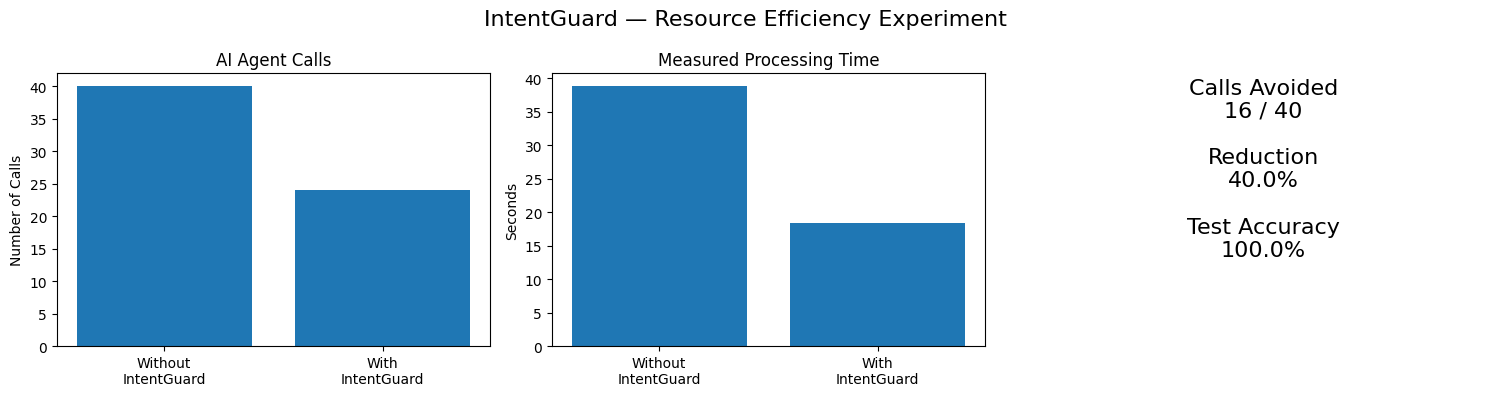

In [173]:
import matplotlib.pyplot as plt

# Values from our experiment
total = metrics["total_messages"]
calls_without = metrics["ai_calls_without_guard"]
calls_with = metrics["ai_calls_with_guard"]
time_without = metrics["time_without_guard"]
time_with = metrics["time_with_guard"]
accuracy = metrics["accuracy"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# AI calls
axes[0].bar(
    ["Without\nIntentGuard", "With\nIntentGuard"],
    [calls_without, calls_with]
)
axes[0].set_title("AI Agent Calls")
axes[0].set_ylabel("Number of Calls")

# Time
axes[1].bar(
    ["Without\nIntentGuard", "With\nIntentGuard"],
    [time_without, time_with]
)
axes[1].set_title("Measured Processing Time")
axes[1].set_ylabel("Seconds")

# Summary
axes[2].axis("off")
axes[2].text(
    0.5, 0.65,
    f"Calls Avoided\n{calls_without - calls_with} / {total}\n\n"
    f"Reduction\n{(calls_without - calls_with) / total * 100:.1f}%\n\n"
    f"Test Accuracy\n{accuracy:.1f}%",
    ha="center",
    va="center",
    fontsize=16
)

plt.suptitle("IntentGuard — Resource Efficiency Experiment", fontsize=16)
plt.tight_layout()
plt.show()

# What is IntentGuard?

IntentGuard is a lightweight pre-inference gate designed to reduce unnecessary AI-agent computation.

Instead of sending every user message directly to an AI agent, IntentGuard first analyzes the message and decides whether an AI response is actually required.

### Example

"Thank you"  
→ NO_ACTION  
→ AI agent is not called

"What is RAG?"  
→ TASK  
→ AI agent is called

"Search the latest AI news"  
→ TASK  
→ Web search tool is selected

### Why does this matter?

AI agents can consume compute, tokens, time, and API resources every time they perform inference or use tools.

IntentGuard attempts to stop non-actionable messages before that computation occurs.

The system is designed to be conservative: when a message appears to require a genuine task, it should be passed to the AI system rather than silently discarded.


# How IntentGuard Works

IntentGuard uses multiple layers to make its decision:

1. **Message analysis**  
   The incoming message is examined for obvious task signals.

2. **Semantic similarity**  
   The message is compared with examples of actionable and non-actionable messages using a lightweight embedding model.

3. **Context awareness**  
   Recent conversation history is considered so that the meaning of a message is not judged in isolation.

4. **Decision gate**

```text
                 USER MESSAGE
                      ↓
                IntentGuard
                      ↓
          ┌───────────┴───────────┐
          ↓                       ↓
      NO_ACTION                 TASK
          ↓                       ↓
       STOP                 AI AGENT
                                  ↓
                         Tool / LLM execution

# Experimental Results

IntentGuard was evaluated on a 40-message test set containing both non-actionable messages and genuine tasks.

### Results

| Metric | Result |
|---|---:|
| Total messages | 40 |
| AI calls without IntentGuard | 40 |
| AI calls with IntentGuard | 24 |
| Calls avoided | 16 |
| Call reduction | 40% |
| Test classification accuracy | 100% |
| Time without IntentGuard | 38.80 s |
| Time with IntentGuard | 18.32 s |
| Measured time reduction | 52.8% |

### Interpretation

In this experiment, IntentGuard prevented 16 of 40 messages from reaching the AI agent.

The measured end-to-end processing time decreased from 38.80 seconds to 18.32 seconds.

These results are from our local 40-message benchmark and demonstrate the potential of a pre-inference gate to reduce unnecessary AI-agent computation.

They should not be interpreted as universal performance guarantees; larger and more diverse evaluations are needed.

# Limitations

This project is a prototype and has several limitations:

- The current evaluation uses a relatively small 40-message test dataset.
- Some classification decisions use predefined examples and rules.
- The local FLAN-T5 model is used for demonstration and is not representative of production-grade LLM quality.
- The measured time depends on the local Colab runtime and hardware.
- The current weather and web-search tools are simple demonstrations rather than production APIs.
- Larger and more diverse datasets are required to properly evaluate false positives and false negatives.

### Future Work

Future versions could include:

- A trained intent-classification model
- Larger benchmark datasets
- Confidence thresholds and human-in-the-loop handling
- Token and API-cost measurements
- Energy/compute-efficiency measurements
- Integration as middleware between users and production AI agents
- Evaluation across different LLMs and agent frameworks

# Project Components

IntentGuard is organized into the following components:

| Component | Purpose |
|---|---|
| IntentGuard | Decides whether AI action is required |
| Semantic Model | Understands message meaning |
| Context Layer | Uses recent conversation context |
| AI Agent | Handles genuine tasks |
| Web Search | Retrieves current information |
| Weather Tool | Retrieves live weather information |
| PDF Q&A | Answers questions from an uploaded PDF |
| Evaluation | Measures accuracy and resource savings |
| Dashboard | Visualizes experimental results |

### Complete Flow

```text
User Message
     ↓
IntentGuard
     ↓
Context + Semantic Analysis
     ↓
 ┌───────────────┐
 │               │
NO_ACTION       TASK
 │               │
 ↓               ↓
STOP          Tool Router
                  ↓
        ┌─────────┼─────────┐
        ↓         ↓         ↓
      Web      Weather     PDF
     Search     Tool       Q&A
        └─────────┼─────────┘
                  ↓
              AI Agent

In [174]:
import os
from google.colab import userdata

os.environ["LANGSMITH_API_KEY"] = userdata.get("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "IntentGuard"

print("✅ LangSmith configured securely")

✅ LangSmith configured securely


In [176]:
from langsmith import traceable

print("✅ LangSmith traceable imported")

✅ LangSmith traceable imported


In [177]:
@traceable(name="IntentGuard")
def traced_intent_guard(message):
    decision = intent_guard(message)
    return {
        "message": message,
        "decision": decision
    }

print(traced_intent_guard("What is RAG?"))

{'message': 'What is RAG?', 'decision': 'TASK'}


In [178]:
@traceable(name="IntentGuard_Full_Workflow")
def traced_full_workflow(message):

    decision = intent_guard(message)

    if decision == "NO_ACTION":
        return {
            "message": message,
            "decision": "NO_ACTION",
            "action": "AI agent not called"
        }

    route = choose_tool(message)

    if route == "WEB_SEARCH":
        result = web_search(message)

    elif route == "WEATHER":
        result = get_weather("Jammu")

    elif route == "PDF_QA":
        result = pdf_qa(message)

    elif route == "AI_AGENT":
        result = run_agent(message)

    else:
        result = "Unknown route"

    return {
        "message": message,
        "decision": "TASK",
        "route": route,
        "result": result
    }


result = traced_full_workflow("What is the weather today?")
print(result)

{'message': 'What is the weather today?', 'decision': 'TASK', 'route': 'WEATHER', 'result': {'city': 'Jammu', 'temperature': '34°C', 'condition': 'Smoky haze', 'humidity': '41%'}}


# Conclusion

IntentGuard demonstrates a simple approach to making AI-agent systems more resource-efficient.

Instead of treating every incoming message as a reason to invoke an AI system, IntentGuard introduces a lightweight decision layer before inference.

The prototype combines:

- Rule-based task signals
- Semantic similarity
- Conversation context
- Tool routing
- AI-agent execution
- LangSmith tracing

In our 40-message benchmark, the system avoided 16 of 40 AI-agent calls while maintaining 100% classification accuracy on the test set.

The experiment suggests that pre-inference gating can be a useful direction for reducing unnecessary AI computation.

The next stage is to evaluate IntentGuard on larger datasets and production-like AI workloads.